# Audio + Text + Video Fusion — Decision-Level Ensemble

Combines:
- **Audio predictions** from FYP TriDep (wav2vec2, video LOSOCV)
- **Video predictions** from FYP TriDep (CLNF facial action units, LOSOCV)
- **Text predictions** from bias-in-daic-woz InducT-GCN best Participant model (dev set, 35 subjects)

Fusion is done at **decision level** — no retraining needed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

DRIVE = '/content/drive/MyDrive/DAIC'

# FYP best model — fused audio+video+text predictions (all 189 subjects, LOSOCV)
FYP_FUSED_CSV = f'{DRIVE}/losocv_predictions_smote_focal.csv'

# bias-in-daic-woz — best Participant InducT-GCN text model (35 dev subjects)
TEXT_JSON = f'{DRIVE}/output/Participant/9_induct-gcn[original-features250]/results_predictions.json'

# Dev-set participant IDs (35 subjects, in evaluation order)
DEV_IDS_TXT = f'{DRIVE}/AVEC_16_data/dev_IDS.txt'

OUT_DIR = f'{DRIVE}/fusion_results'
os.makedirs(OUT_DIR, exist_ok=True)
print('Paths set.')


Paths set.


## 1. Load Dev Participant IDs


In [ ]:
dev_df     = pd.read_csv(DEV_IDS_TXT, sep='\t')
dev_ids    = dev_df['original_ID'].tolist()
dev_labels = dev_df['category'].tolist()
y_true     = np.array(dev_labels)

print(f'Dev set: {len(dev_ids)} participants')
print(f'Depressed: {y_true.sum()}  Control: {(y_true==0).sum()}')


Dev set: 35 participants
Depressed: 12  Control: 23


## 2. Load FYP Fused Model Predictions


In [ ]:
fyp_df  = pd.read_csv(FYP_FUSED_CSV)
fyp_dev = fyp_df[fyp_df['participant_id'].isin(dev_ids)].copy()
fyp_dev = fyp_dev.set_index('participant_id').reindex(dev_ids).reset_index()

fyp_prob = fyp_dev['y_prob'].values.astype(float)
fyp_pred = fyp_dev['y_pred'].values.astype(int)

print(f'FYP fused predictions: {len(fyp_dev)} dev subjects found')
print(f'FYP Fused — Accuracy: {accuracy_score(y_true, fyp_pred):.4f}  F1(dep): {f1_score(y_true, fyp_pred, zero_division=0):.4f}')


FYP fused predictions: 35 dev subjects found
FYP Fused — Accuracy: 0.7143  F1(dep): 0.5455


## 3. Load InducT-GCN Text Predictions


In [ ]:
with open(TEXT_JSON) as f:
    text_data = json.load(f)

text_pred = np.array(text_data['y_pred'])
text_prob = np.array(text_data.get('y_prob', text_data['y_pred']), dtype=float)

print(f'InducT-GCN — Accuracy: {accuracy_score(y_true, text_pred):.4f}  F1(dep): {f1_score(y_true, text_pred, zero_division=0):.4f}')


InducT-GCN — Accuracy: 0.8000  F1(dep): 0.7407


## 4. Fusion Strategies


In [ ]:
def metrics(y_true, y_pred, y_prob=None, name=''):
    row = {
        'Model'           : name,
        'Accuracy'        : round(accuracy_score(y_true, y_pred), 4),
        'Precision (dep)' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall (dep)'    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 (dep)'        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'F1 (weighted)'   : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }
    if y_prob is not None:
        try:   row['ROC-AUC'] = round(roc_auc_score(y_true, y_prob), 4)
        except: row['ROC-AUC'] = float('nan')
    else:
        row['ROC-AUC'] = float('nan')
    return row

results = []

# ── FYP unimodal baselines (from saved unimodal_comparison.csv, LOSOCV all subjects) ──
try:
    uni = pd.read_csv(f'{DRIVE}/figs/unimodal_comparison.csv')
    uni = uni.rename(columns={'Modality': 'Model'})
    uni['Model'] = 'FYP ' + uni['Model']
    # add missing columns
    for col in ['ROC-AUC']:
        if col not in uni.columns:
            uni[col] = float('nan')
    results += uni.to_dict('records')
    print('Loaded FYP unimodal results from Drive.')
except Exception as e:
    print(f'Could not load unimodal_comparison.csv: {e}')

# ── FYP fused model on dev set ────────────────────────────────────────────────
results.append(metrics(y_true, fyp_pred,  fyp_prob,  'FYP Fused (A+V+T)'))

# ── InducT-GCN text only ──────────────────────────────────────────────────────
results.append(metrics(y_true, text_pred, text_prob, 'InducT-GCN Text'))

# ── fusion strategies ─────────────────────────────────────────────────────────
avg = (fyp_prob + text_prob) / 2
results.append(metrics(y_true, (avg >= 0.5).astype(int), avg, 'Average (FYP + InducT-GCN)'))

w1 = 0.6 * fyp_prob + 0.4 * text_prob
results.append(metrics(y_true, (w1 >= 0.5).astype(int), w1, 'Weighted FYP=0.6 Text=0.4'))

w2 = 0.4 * fyp_prob + 0.6 * text_prob
results.append(metrics(y_true, (w2 >= 0.5).astype(int), w2, 'Weighted FYP=0.4 Text=0.6'))

or_pred  = ((fyp_pred + text_pred) >= 1).astype(int)
and_pred = ((fyp_pred + text_pred) == 2).astype(int)
results.append(metrics(y_true, or_pred,  None, 'OR vote'))
results.append(metrics(y_true, and_pred, None, 'AND vote'))

df_results = pd.DataFrame(results)
print('\n' + '=' * 70)
print('FULL COMPARISON — FYP Unimodal / Fused + InducT-GCN Fusion')
print('=' * 70)
print(df_results.to_string(index=False))
df_results.to_csv(f'{OUT_DIR}/fusion_comparison.csv', index=False)


Loaded FYP unimodal results from Drive.

FULL COMPARISON — FYP Unimodal / Fused + InducT-GCN Fusion
                     Model  Accuracy  Precision (dep)  Recall (dep)  F1 (dep)  F1 (weighted)  ROC-AUC
                  FYP Text    0.6931           0.4821        0.4821    0.4821         0.6931   0.6814
                 FYP Audio    0.5132           0.3000        0.4821    0.3699         0.5342   0.5330
                 FYP Video    0.4815           0.2812        0.4821    0.3553         0.5038   0.5067
         FYP Fused (T+A+V)    0.7090           0.5116        0.3929    0.4444         0.6967   0.6265
         FYP Fused (A+V+T)    0.7143           0.6000        0.5000    0.5455         0.7073   0.6413
           InducT-GCN Text    0.8000           0.6667        0.8333    0.7407         0.8041   0.8080
Average (FYP + InducT-GCN)    0.8000           0.6667        0.8333    0.7407         0.8041   0.8116
 Weighted FYP=0.6 Text=0.4    0.7714           0.6667        0.6667    0.6667       

## 6. Visualizations

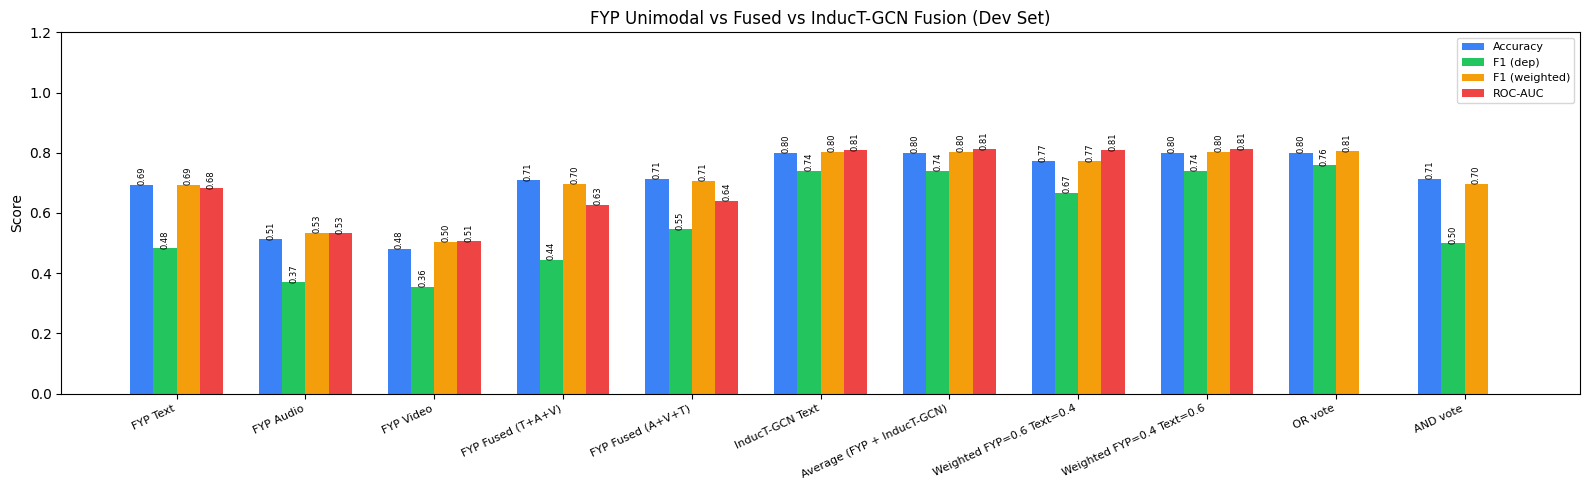

Saved fusion_bar.png


In [ ]:
# ── 6a. Comparison bar chart ──────────────────────────────────────────────────
metric_cols = ['Accuracy', 'F1 (dep)', 'F1 (weighted)', 'ROC-AUC']
colors      = ['#3b82f6', '#22c55e', '#f59e0b', '#ef4444']

strategies = df_results['Model'].tolist()
x = np.arange(len(strategies))
w = 0.18

fig, ax = plt.subplots(figsize=(16, 5))
for j, (col, clr) in enumerate(zip(metric_cols, colors)):
    vals = df_results[col].fillna(0).tolist()
    bars = ax.bar(x + j * w, vals, w, label=col, color=clr)
    for b, v in zip(bars, vals):
        if v > 0:
            ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.2f}',
                    ha='center', fontsize=6, rotation=90)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(strategies, rotation=25, ha='right', fontsize=8)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score')
ax.set_title('FYP Unimodal vs Fused vs InducT-GCN Fusion (Dev Set)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fusion_bar.png', dpi=150)
plt.show()
print('Saved fusion_bar.png')


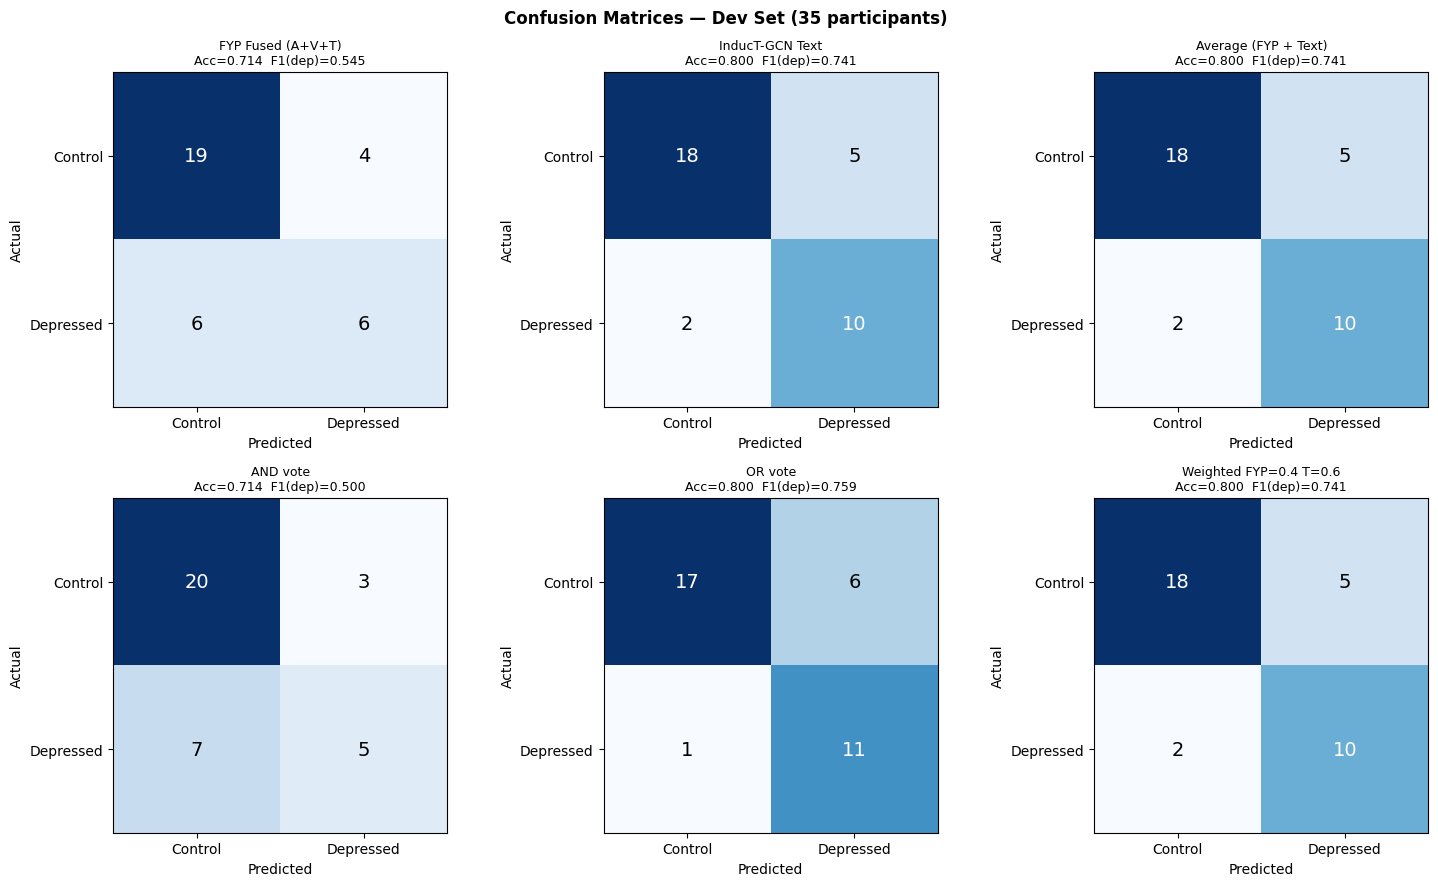

Saved fusion_confusion_matrices.png


In [ ]:
# ── 6b. Confusion matrices for key strategies ─────────────────────────────────
key_strategies = {
    'FYP Fused (A+V+T)'       : fyp_pred,
    'InducT-GCN Text'         : text_pred,
    'Average (FYP + Text)'    : (avg >= 0.5).astype(int),
    'AND vote'                : and_pred,
    'OR vote'                 : or_pred,
    'Weighted FYP=0.4 T=0.6' : (w2 >= 0.5).astype(int),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, key_strategies.items()):
    cm = confusion_matrix(y_true, preds)
    ax.imshow(cm, cmap='Blues')
    for (r, c), v in np.ndenumerate(cm):
        ax.text(c, r, str(v), ha='center', va='center', fontsize=14,
                color='white' if v > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Control', 'Depressed'])
    ax.set_yticklabels(['Control', 'Depressed'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    f1  = f1_score(y_true, preds, zero_division=0)
    acc = accuracy_score(y_true, preds)
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1(dep)={f1:.3f}', fontsize=9)

plt.suptitle('Confusion Matrices — Dev Set (35 participants)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fusion_confusion_matrices.png', dpi=150)
plt.show()
print('Saved fusion_confusion_matrices.png')


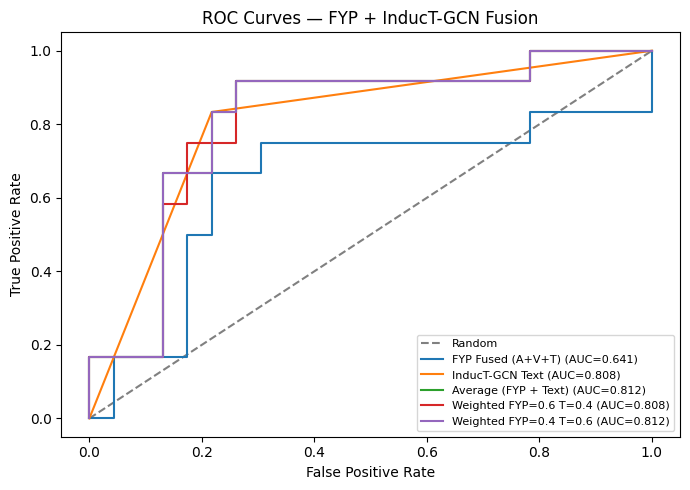

Saved fusion_roc.png


In [ ]:
# ── 6c. ROC curves ────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

roc_strategies = {
    'FYP Fused (A+V+T)'      : fyp_prob,
    'InducT-GCN Text'        : text_prob,
    'Average (FYP + Text)'   : avg,
    'Weighted FYP=0.6 T=0.4' : w1,
    'Weighted FYP=0.4 T=0.6' : w2,
}

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
for name, probs in roc_strategies.items():
    try:
        auc = roc_auc_score(y_true, probs)
        fpr, tpr, _ = roc_curve(y_true, probs)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    except Exception as e:
        print(f'Skipping {name}: {e}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — FYP + InducT-GCN Fusion')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fusion_roc.png', dpi=150)
plt.show()
print('Saved fusion_roc.png')


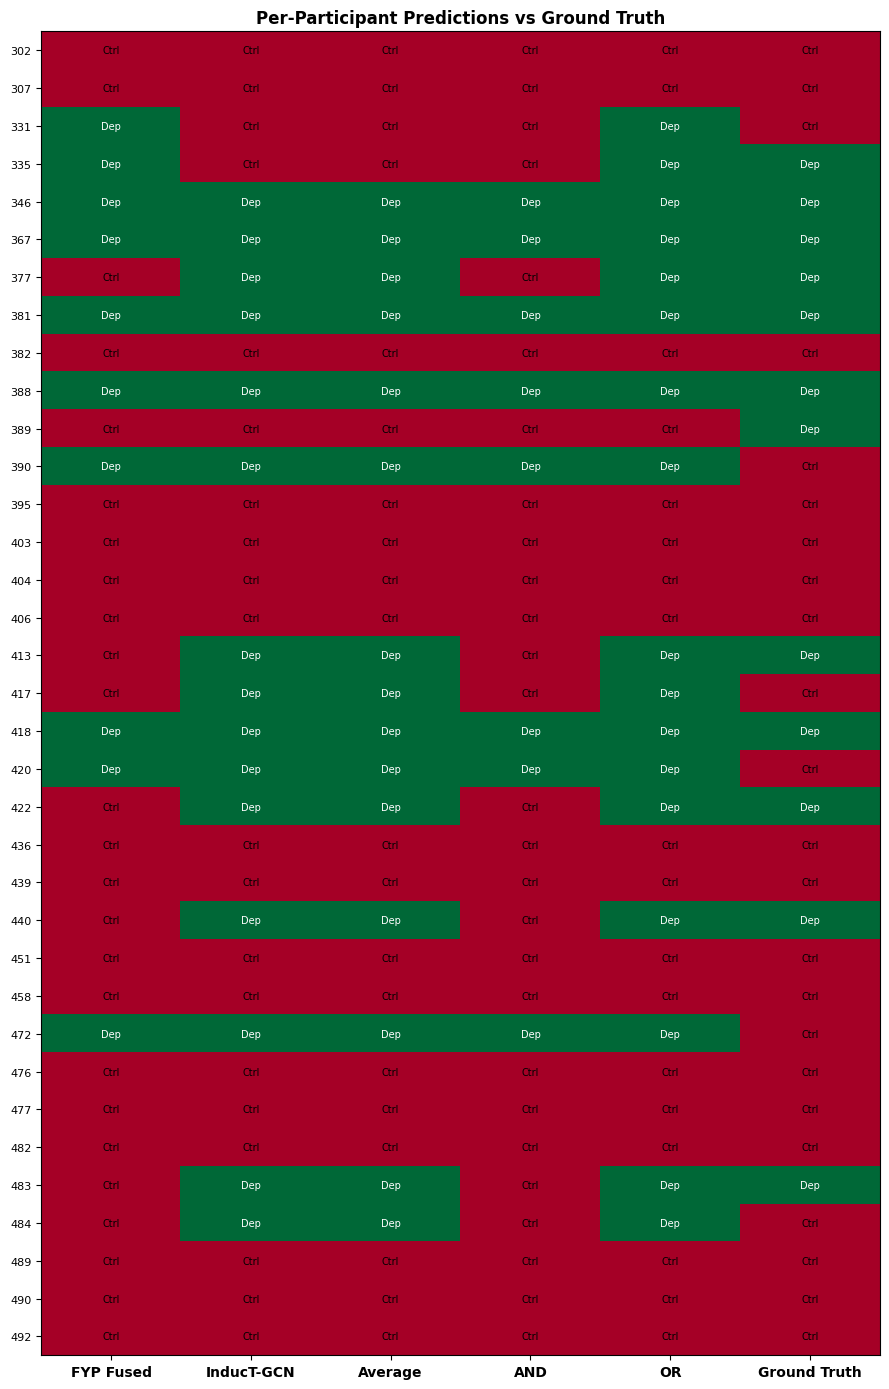

Saved fusion_heatmap.png


In [ ]:
# ── 6d. Per-participant prediction heatmap ────────────────────────────────────
preds_matrix = np.stack([
    fyp_pred,
    text_pred,
    (avg   >= 0.5).astype(int),
    and_pred,
    or_pred,
    y_true,
], axis=1)

col_labels = ['FYP Fused', 'InducT-GCN', 'Average', 'AND', 'OR', 'Ground Truth']
row_labels  = [str(pid) for pid in dev_ids]

fig, ax = plt.subplots(figsize=(9, 14))
ax.imshow(preds_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels, fontweight='bold')
ax.set_yticklabels(row_labels, fontsize=8)

for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = preds_matrix[i, j]
        ax.text(j, i, 'Dep' if val == 1 else 'Ctrl',
                ha='center', va='center', fontsize=7,
                color='white' if val == 1 else 'black')

ax.set_title('Per-Participant Predictions vs Ground Truth', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fusion_heatmap.png', dpi=150)
plt.show()
print('Saved fusion_heatmap.png')


In [ ]:
# ── 6e. Best strategy summary ─────────────────────────────────────────────────
best_f1  = df_results.loc[df_results['F1 (dep)'].idxmax()]
best_acc = df_results.loc[df_results['Accuracy'].idxmax()]
best_wf1 = df_results.loc[df_results['F1 (weighted)'].idxmax()]

print('=' * 55)
print('BEST BY F1 (Depressed):')
print(f"  {best_f1['Model']}")
print(f"  Accuracy : {best_f1['Accuracy']}")
print(f"  F1 (dep) : {best_f1['F1 (dep)']}")
print(f"  F1 (wt)  : {best_f1['F1 (weighted)']}")
print()
print('BEST BY ACCURACY:')
print(f"  {best_acc['Model']}  →  {best_acc['Accuracy']}")
print()
print('BEST BY WEIGHTED F1:')
print(f"  {best_wf1['Model']}  →  {best_wf1['F1 (weighted)']}")
print('=' * 55)

# save full merged predictions
pd.DataFrame({
    'participant_id'   : dev_ids,
    'y_true'           : y_true,
    'fyp_fused_prob'   : fyp_prob,
    'fyp_fused_pred'   : fyp_pred,
    'text_prob'        : text_prob,
    'text_pred'        : text_pred,
    'avg_pred'         : (avg >= 0.5).astype(int),
    'and_pred'         : and_pred,
    'or_pred'          : or_pred,
}).to_csv(f'{OUT_DIR}/merged_predictions.csv', index=False)
print(f'\nSaved merged_predictions.csv and all charts to {OUT_DIR}')


BEST BY F1 (Depressed):
  OR vote
  Accuracy : 0.8
  F1 (dep) : 0.7586
  F1 (wt)  : 0.805

BEST BY ACCURACY:
  InducT-GCN Text  →  0.8

BEST BY WEIGHTED F1:
  OR vote  →  0.805

Saved merged_predictions.csv and all charts to /content/drive/MyDrive/DAIC/fusion_results
